In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ── Style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 130,
})

ATTRITION_COLOR  = '#E05C3A'   # warm red  → left the company
RETAINED_COLOR   = '#2E86AB'   # blue      → stayed
NEUTRAL_COLOR    = '#7A8FA6'
HIGHLIGHT_COLOR  = '#F4A261'


In [8]:
# ── Load & Prepare
df = pd.read_csv('HR-Employee-Attrition.csv')
df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)

# Decode ordinal columns for readable labels
edu_map   = {1:'Below College',2:'College',3:'Bachelor',4:'Master',5:'Doctor'}
sat_map   = {1:'Low',2:'Medium',3:'High',4:'Very High'}
wlb_map   = {1:'Bad',2:'Good',3:'Better',4:'Best'}
inv_map   = {1:'Low',2:'Medium',3:'High',4:'Very High'}

df['Education_Label']       = df['Education'].map(edu_map)
df['JobSatisfaction_Label'] = df['JobSatisfaction'].map(sat_map)
df['WorkLifeBalance_Label'] = df['WorkLifeBalance'].map(wlb_map)
df['JobInvolvement_Label']  = df['JobInvolvement'].map(inv_map)

df['AgeBin'] = pd.cut(df['Age'],
                      bins=[18,25,30,35,45,60],
                      labels=['18–25','26–30','31–35','36–45','46–60'])
df['YearsBin'] = pd.cut(df['YearsAtCompany'],
                        bins=[0,2,5,10,20,100],
                        labels=['0–2 yrs','3–5 yrs','6–10 yrs','11–20 yrs','20+ yrs'])

total       = len(df)
n_left      = df['Attrition_Flag'].sum()
attrition_pct = n_left / total * 100

print("=" * 55)
print("  IBM HR ATTRITION — QUICK SUMMARY")
print("=" * 55)
print(f"  Total employees  : {total:,}")
print(f"  Employees left   : {n_left}  ({attrition_pct:.1f}%)")
print(f"  Employees stayed : {total - n_left}  ({100-attrition_pct:.1f}%)")
print("=" * 55)


  IBM HR ATTRITION — QUICK SUMMARY
  Total employees  : 1,470
  Employees left   : 237  (16.1%)
  Employees stayed : 1233  (83.9%)


Text(0.5, 1.0, 'Overall Attrition Rate')

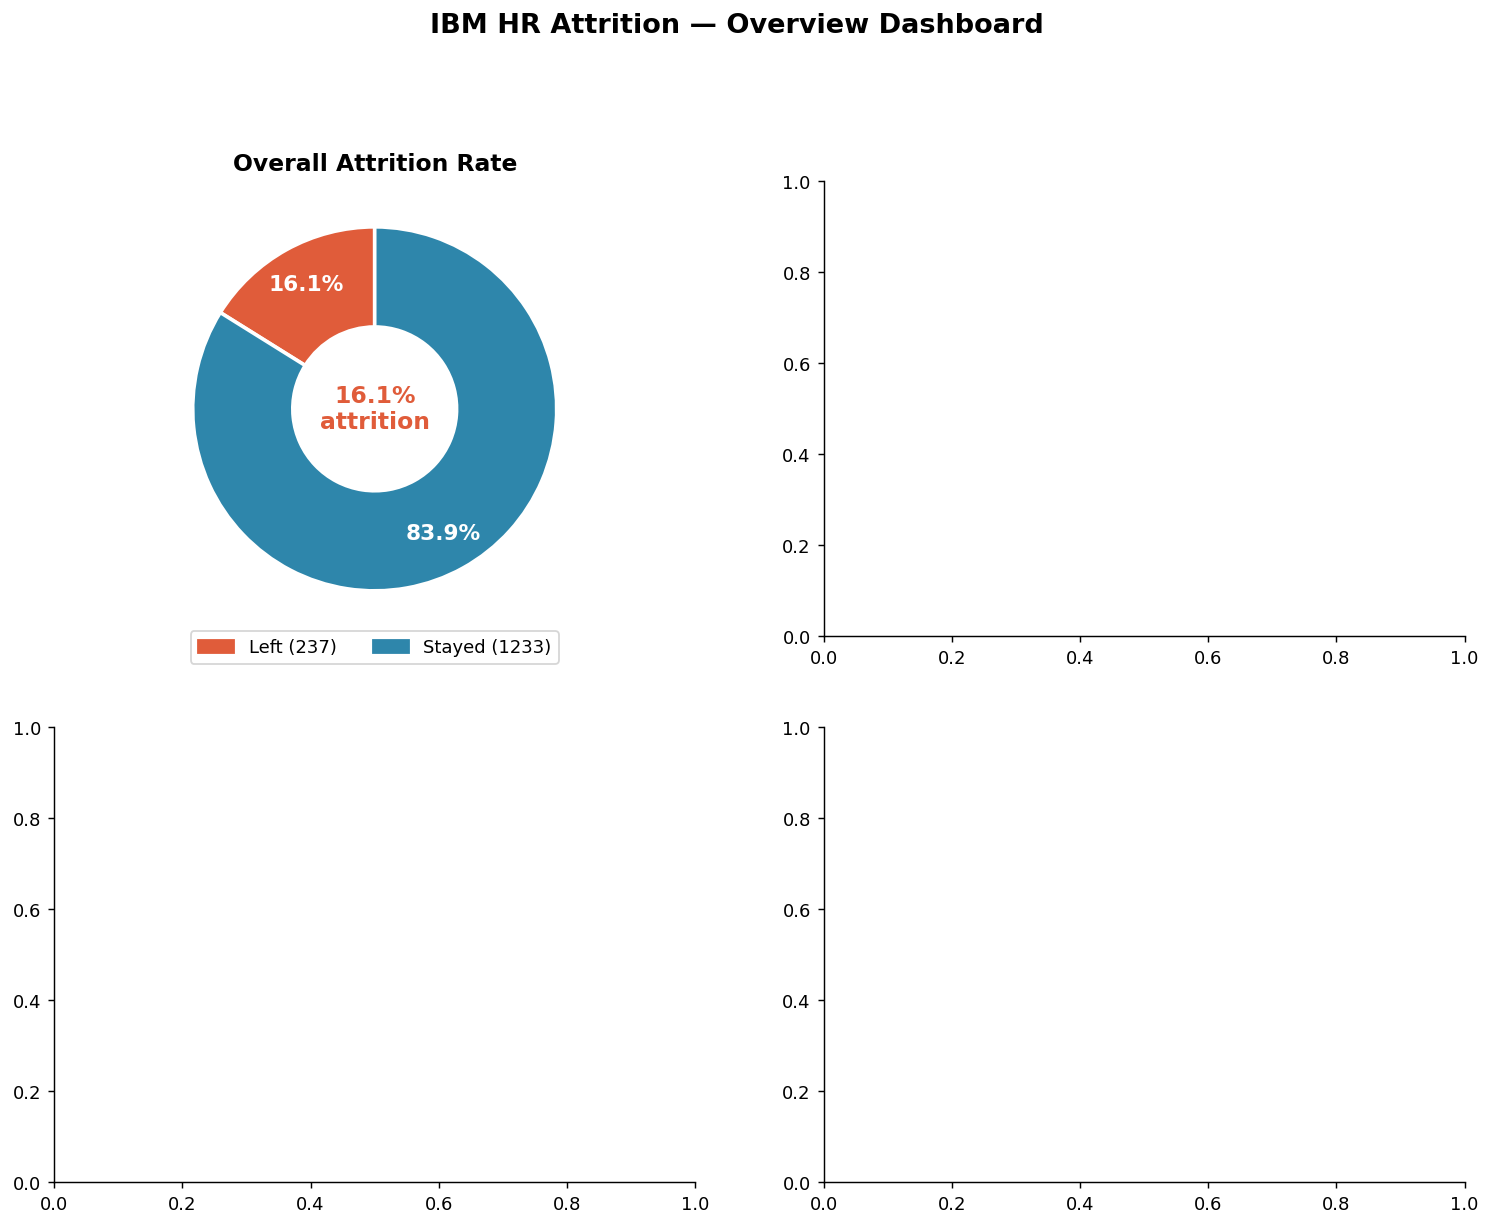

In [10]:
#FIGURE 1 — Overview Dashboard (2 × 2)
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle('IBM HR Attrition — Overview Dashboard', fontsize=15,
              fontweight='bold', y=1.01)

# ── 1A  Overall attrition donut ────────────────────────────────────────────
ax = axes[0, 0]
sizes  = [n_left, total - n_left]
colors = [ATTRITION_COLOR, RETAINED_COLOR]
wedges, texts, autotexts = ax.pie(
    sizes, colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
ax.text(0, 0, f'{attrition_pct:.1f}%\nattrition', ha='center', va='center',
        fontsize=13, fontweight='bold', color=ATTRITION_COLOR)
ax.legend(handles=[mpatches.Patch(color=ATTRITION_COLOR, label=f'Left ({n_left})'),
                   mpatches.Patch(color=RETAINED_COLOR,  label=f'Stayed ({total-n_left})')],
          loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=10)
ax.set_title('Overall Attrition Rate')


In [13]:
# ── 1B  Attrition by Department ───────────────────────────────────────────
ax = axes[0, 1]
dept = df.groupby('Department')['Attrition_Flag'].mean().mul(100).sort_values()
bars = ax.barh(dept.index, dept.values,
               color=[ATTRITION_COLOR if v > 16 else RETAINED_COLOR for v in dept.values],
               edgecolor='white', height=0.5)
for bar, val in zip(bars, dept.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.axvline(attrition_pct, color=NEUTRAL_COLOR, linestyle='--', linewidth=1.2,
           label=f'Company avg {attrition_pct:.1f}%')
ax.legend(fontsize=9)
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Department')
ax.set_xlim(0, 30)



(0.0, 30.0)

In [14]:
# ── 1C  Attrition by Age Group ────────────────────────────────────────────
ax = axes[1, 0]
age = df.groupby('AgeBin', observed=True)['Attrition_Flag'].mean().mul(100)
bars = ax.bar(age.index, age.values,
              color=[ATTRITION_COLOR if v > 20 else
                     HIGHLIGHT_COLOR if v > 16 else RETAINED_COLOR
                     for v in age.values],
              edgecolor='white', width=0.6)
for bar, val in zip(bars, age.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(attrition_pct, color=NEUTRAL_COLOR, linestyle='--', linewidth=1.2,
           label=f'Avg {attrition_pct:.1f}%')
ax.legend(fontsize=9)
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Age Group')
ax.set_ylim(0, 45)

(0.0, 45.0)

In [15]:
# ── 1D  Monthly Income distribution ──────────────────────────────────────
ax = axes[1, 1]
for label, color in [('No', RETAINED_COLOR), ('Yes', ATTRITION_COLOR)]:
    subset = df[df['Attrition'] == label]['MonthlyIncome']
    ax.hist(subset, bins=30, alpha=0.65, color=color, edgecolor='white',
            label=f"{'Stayed' if label=='No' else 'Left'} (avg ${subset.mean():,.0f})")
ax.set_xlabel('Monthly Income ($)')
ax.set_ylabel('Number of Employees')
ax.set_title('Monthly Income Distribution: Left vs Stayed')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig1_overview_dashboard.png', bbox_inches='tight')
plt.close()
print("\n[Saved] fig1_overview_dashboard.png")




[Saved] fig1_overview_dashboard.png


Text(0.5, 1.01, 'Key Drivers of Employee Attrition')

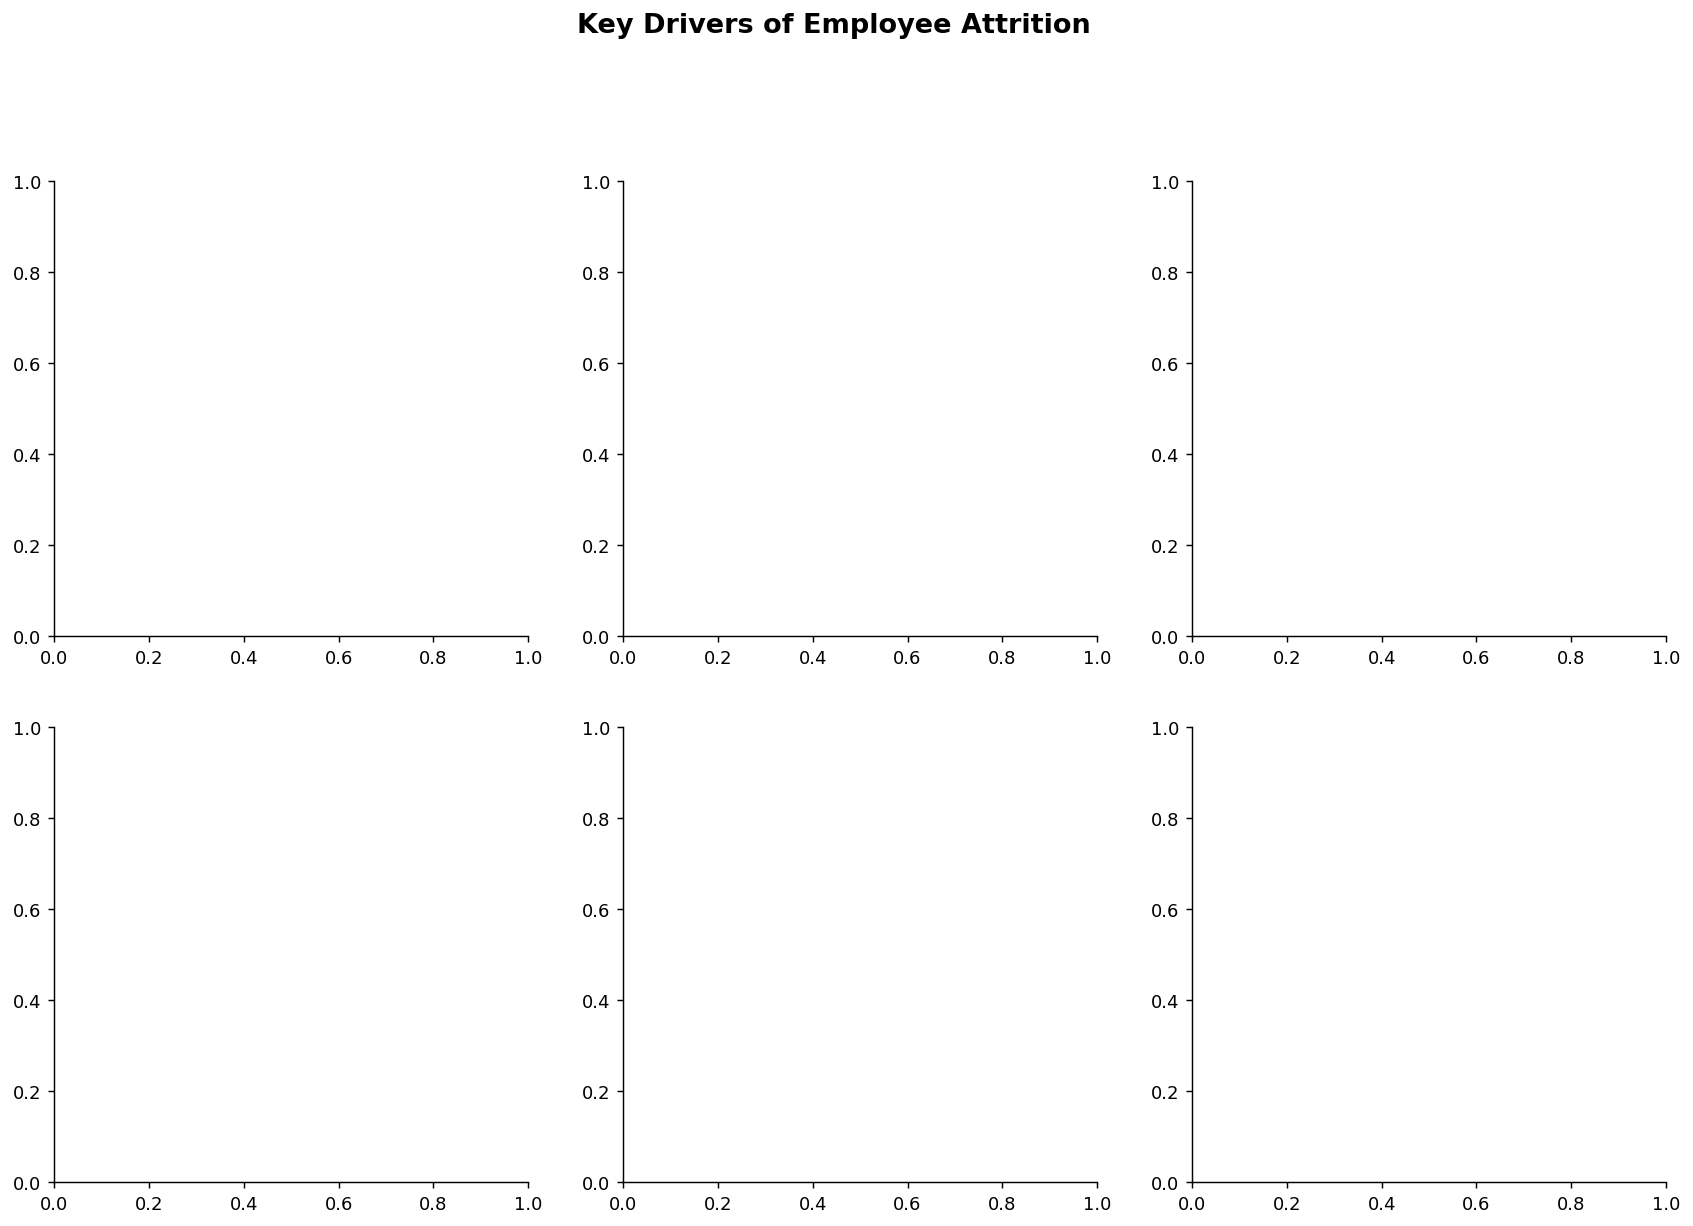

In [16]:
#FIGURE 2 — Top Risk Factors
fig2, axes = plt.subplots(2, 3, figsize=(16, 10))
fig2.suptitle('Key Drivers of Employee Attrition', fontsize=15,
              fontweight='bold', y=1.01)



In [17]:
# ── 2A  Overtime ──────────────────────────────────────────────────────────
ax = axes[0, 0]
ot = df.groupby('OverTime')['Attrition_Flag'].mean().mul(100)
bars = ax.bar(['No Overtime', 'Overtime'], ot.values,
              color=[RETAINED_COLOR, ATTRITION_COLOR], edgecolor='white', width=0.5)
for bar, val in zip(bars, ot.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Overtime is the #1 Risk Factor')
ax.set_ylim(0, 40)
ax.text(1, 32, f'3× higher\nrisk', ha='center', fontsize=10,
        color=ATTRITION_COLOR, fontweight='bold')

Text(1, 32, '3× higher\nrisk')

In [18]:
# ── 2B  Business Travel ───────────────────────────────────────────────────
ax = axes[0, 1]
travel_order = ['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']
travel_labels = ['No Travel', 'Rare Travel', 'Frequent Travel']
travel = df.groupby('BusinessTravel')['Attrition_Flag'].mean().mul(100).reindex(travel_order)
bars = ax.bar(travel_labels, travel.values,
              color=[RETAINED_COLOR, HIGHLIGHT_COLOR, ATTRITION_COLOR],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, travel.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Frequent Travellers Leave 3× More')
ax.set_ylim(0, 35)

(0.0, 35.0)

In [19]:
# ── 2C  Marital Status ────────────────────────────────────────────────────
ax = axes[0, 2]
mar_order = ['Single', 'Married', 'Divorced']
mar = df.groupby('MaritalStatus')['Attrition_Flag'].mean().mul(100).reindex(mar_order)
bars = ax.bar(mar_order, mar.values,
              color=[ATTRITION_COLOR, RETAINED_COLOR, RETAINED_COLOR],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, mar.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Single Employees Leave 2.5× More')
ax.set_ylim(0, 35)

(0.0, 35.0)

In [20]:
# ── 2D  Job Role ──────────────────────────────────────────────────────────
ax = axes[1, 0]
role = df.groupby('JobRole')['Attrition_Flag'].mean().mul(100).sort_values(ascending=True)
colors_role = [ATTRITION_COLOR if v > 20 else
               HIGHLIGHT_COLOR if v > 15 else RETAINED_COLOR
               for v in role.values]
bars = ax.barh(role.index, role.values, color=colors_role, edgecolor='white', height=0.6)
for bar, val in zip(bars, role.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.axvline(attrition_pct, color=NEUTRAL_COLOR, linestyle='--', linewidth=1.2,
           label=f'Avg {attrition_pct:.1f}%')
ax.legend(fontsize=9)
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition by Job Role')
ax.set_xlim(0, 50)

(0.0, 50.0)

In [21]:
# ── 2E  Years at Company ──────────────────────────────────────────────────
ax = axes[1, 1]
tenure = df.groupby('YearsBin', observed=True)['Attrition_Flag'].mean().mul(100)
bars = ax.bar(tenure.index, tenure.values,
              color=[ATTRITION_COLOR if v > 20 else
                     HIGHLIGHT_COLOR if v > 14 else RETAINED_COLOR
                     for v in tenure.values],
              edgecolor='white', width=0.6)
for bar, val in zip(bars, tenure.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(attrition_pct, color=NEUTRAL_COLOR, linestyle='--', linewidth=1.2,
           label=f'Avg {attrition_pct:.1f}%')
ax.legend(fontsize=9)
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('First 2 Years = Highest Flight Risk')
ax.set_ylim(0, 40)

(0.0, 40.0)

In [22]:
# ── 2F  Job Satisfaction ──────────────────────────────────────────────────
ax = axes[1, 2]
sat_order = ['Low','Medium','High','Very High']
sat = (df.groupby('JobSatisfaction_Label')['Attrition_Flag']
         .mean().mul(100).reindex(sat_order))
bars = ax.bar(sat_order, sat.values,
              color=[ATTRITION_COLOR, HIGHLIGHT_COLOR, RETAINED_COLOR, RETAINED_COLOR],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, sat.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Low Job Satisfaction Doubles Risk')
ax.set_ylim(0, 30)

plt.tight_layout()
plt.savefig('fig2_risk_factors.png', bbox_inches='tight')
plt.close()
print("[Saved] fig2_risk_factors.png")

[Saved] fig2_risk_factors.png


Text(0.5, 1.02, 'Deep Dive — Identifying the Highest-Risk Employee Profile')

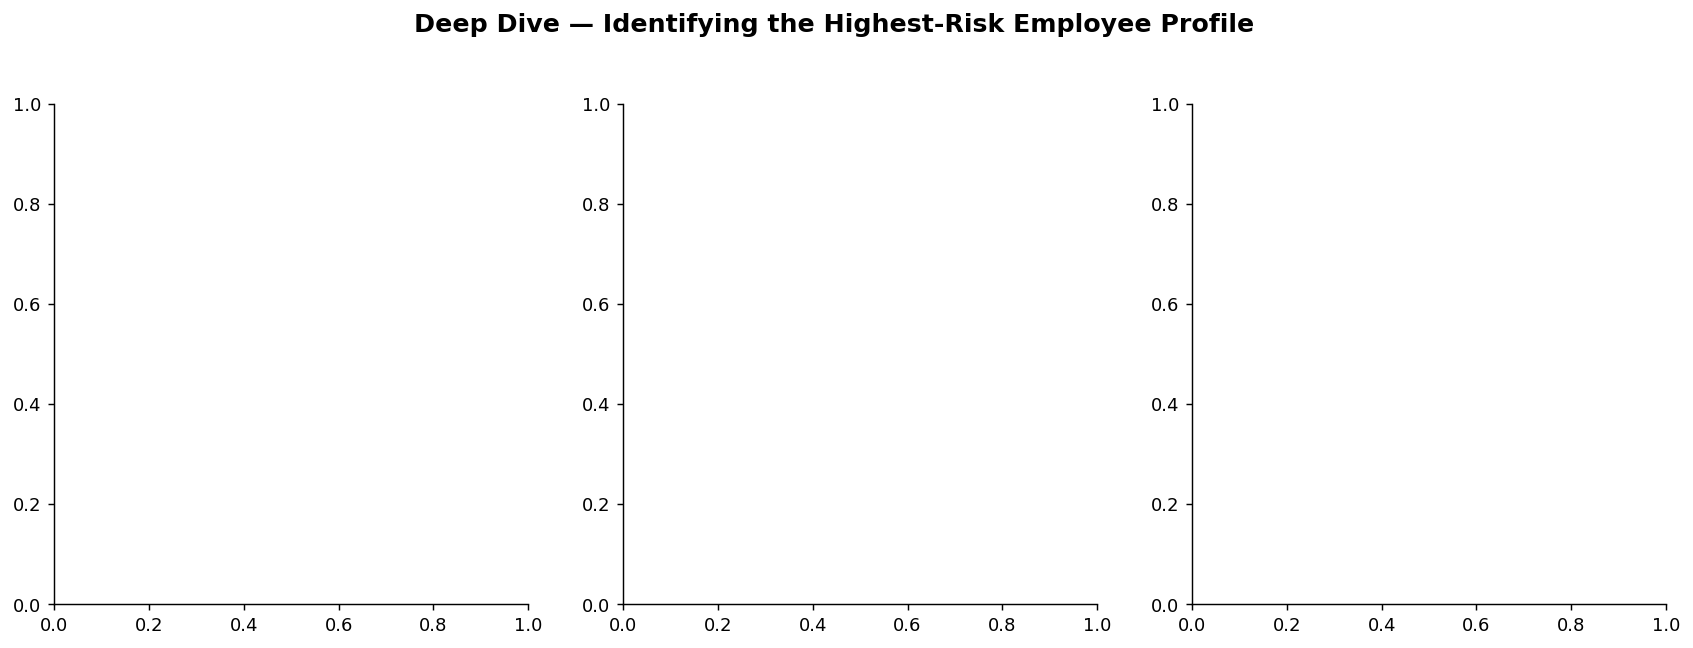

In [23]:
# FIGURE 3 — Deep Dive: The High-Risk Profile
fig3, axes = plt.subplots(1, 3, figsize=(16, 5))
fig3.suptitle('Deep Dive — Identifying the Highest-Risk Employee Profile',
              fontsize=14, fontweight='bold', y=1.02)

In [24]:
# ── 3A  Overtime × Department heatmap ────────────────────────────────────
ax = axes[0]
pivot = df.pivot_table(index='Department', columns='OverTime',
                       values='Attrition_Flag', aggfunc='mean').mul(100)
sns.heatmap(pivot, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Attrition %'},
            vmin=0, vmax=45)
ax.set_title('Overtime × Department\nAttrition Rate (%)')
ax.set_xlabel('Overtime')
ax.set_ylabel('')

Text(222.13888888888886, 0.5, '')

In [25]:
# ── 3B  Work-Life Balance × Overtime ─────────────────────────────────────
ax = axes[1]
wlb_ot = df.groupby(['WorkLifeBalance_Label', 'OverTime'])['Attrition_Flag'].mean().mul(100).unstack()
wlb_order = ['Bad','Good','Better','Best']
wlb_ot = wlb_ot.reindex(wlb_order)
x = np.arange(len(wlb_order))
w = 0.35
bars1 = ax.bar(x - w/2, wlb_ot['No'],  width=w, color=RETAINED_COLOR,  label='No Overtime',  edgecolor='white')
bars2 = ax.bar(x + w/2, wlb_ot['Yes'], width=w, color=ATTRITION_COLOR, label='With Overtime', edgecolor='white')
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.0f}%', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(wlb_order)
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Work-Life Balance × Overtime')
ax.legend(fontsize=9)
ax.set_ylim(0, 65)

(0.0, 65.0)

In [26]:
#3C  Combined high-risk combo bar ─────────────────────────────────────
ax = axes[2]
median_income = df['MonthlyIncome'].median()
combos = {
    'All employees'         : df['Attrition_Flag'].mean() * 100,
    'Overtime only'         : df[df['OverTime']=='Yes']['Attrition_Flag'].mean() * 100,
    'Low income only'       : df[df['MonthlyIncome'] < median_income]['Attrition_Flag'].mean() * 100,
    'Overtime +\nLow income': df[(df['OverTime']=='Yes') &
                                  (df['MonthlyIncome'] < median_income)]['Attrition_Flag'].mean() * 100,
    'Overtime + Low income\n+ Single + Age<30'
                            : df[(df['OverTime']=='Yes') &
                                  (df['MonthlyIncome'] < median_income) &
                                  (df['MaritalStatus']=='Single') &
                                  (df['Age'] < 30)]['Attrition_Flag'].mean() * 100,
}
labels_c = list(combos.keys())
values_c = list(combos.values())
bar_colors = [RETAINED_COLOR, HIGHLIGHT_COLOR, HIGHLIGHT_COLOR,
              ATTRITION_COLOR, '#8B0000']
bars = ax.barh(labels_c, values_c, color=bar_colors, edgecolor='white', height=0.55)
for bar, val in zip(bars, values_c):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Cumulative Risk:\nStacking Risk Factors')
ax.set_xlim(0, 80)

plt.tight_layout()
plt.savefig('fig3_deep_dive.png', bbox_inches='tight')
plt.close()
print("[Saved] fig3_deep_dive.png")



[Saved] fig3_deep_dive.png


In [28]:
# PRINT FINAL INSIGHTS SUMMARY
# ══════════════════════════════════════════════════════════════════════════
median_income = df['MonthlyIncome'].median()
high_risk_rate = df[
    (df['OverTime']=='Yes') &
    (df['MonthlyIncome'] < median_income) &
    (df['MaritalStatus']=='Single') &
    (df['Age'] < 30)
]['Attrition_Flag'].mean() * 100

print("""
╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS & RECOMMENDATIONS                  ║
╠══════════════════════════════════════════════════════════╣

 FINDING 1 — Overtime is the single strongest predictor
   Employees doing overtime leave at 30.5% vs 10.4% without.
   That is nearly 3× the rate. Overtime is not just tiring —
   it is a leading signal that someone is about to quit.

 FINDING 2 — Sales department is the most at-risk
   Sales attrition stands at 20.6%, above the company average
   of 16.1%. Sales Representatives specifically leave at 39.8%
   — the highest of any job role in the company.

 FINDING 3 — New joiners are most vulnerable
   Employees in their first 2 years leave at 28.9%.
   Attrition drops sharply after year 5, suggesting the first
   two years are the critical retention window.

 FINDING 4 — Low earners + overtime = toxic combination
   Employees earning below median AND doing overtime leave at
   43.1%. Combine that with being single and under 30, and
   attrition reaches {:.1f}%.

 FINDING 5 — Frequent travel compounds the risk
   Frequent travellers leave at 24.9% vs 8.0% for non-travellers.
   When combined with overtime, this becomes a compounding risk.
   """.format(high_risk_rate))
print("Analysis complete. Three chart files saved.")



╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS & RECOMMENDATIONS                  ║
╠══════════════════════════════════════════════════════════╣
 
 FINDING 1 — Overtime is the single strongest predictor
   Employees doing overtime leave at 30.5% vs 10.4% without.
   That is nearly 3× the rate. Overtime is not just tiring —
   it is a leading signal that someone is about to quit.
 
 FINDING 2 — Sales department is the most at-risk
   Sales attrition stands at 20.6%, above the company average
   of 16.1%. Sales Representatives specifically leave at 39.8%
   — the highest of any job role in the company.
 
 FINDING 3 — New joiners are most vulnerable
   Employees in their first 2 years leave at 28.9%.
   Attrition drops sharply after year 5, suggesting the first
   two years are the critical retention window.
 
 FINDING 4 — Low earners + overtime = toxic combination
   Employees earning below median AND doing overtime leave at
   43.1%. Combine that wi